In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
TRAJECTORY_LEN = 1001
Z_DIM = 128

In [3]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28
/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.10711266934464, 24.516526859649556)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.54it/s]


In [5]:
x = dataset['observations']
coord_0_min, coord_0_max, coord_1_min, coord_1_max = x[:, 0].min(), x[:, 0].max(), x[:, 1].min(), x[:, 1].max()


def normalize_dataset_coords(dataset):
    dataset[..., 0] = ((dataset[..., 0] - coord_0_min) / (coord_0_max - coord_0_min) - 0.5) * 20
    dataset[..., 1] = ((dataset[..., 1] - coord_1_min) / (coord_1_max - coord_1_min) - 0.5) * 20
    return dataset

In [6]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = normalize_dataset_coords(dataset_trajectories)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])
dataset_rewards = torch.tensor(dataset['rewards'])

dataset_goals = torch.tensor(dataset['infos/goal'])
dataset_goals = normalize_dataset_coords(dataset_goals)




dataset_trajectories = dataset_trajectories[:999*TRAJECTORY_LEN].reshape(-1, TRAJECTORY_LEN, 29)
dataset_actions = dataset_actions[:999*TRAJECTORY_LEN].reshape(-1, TRAJECTORY_LEN, 8)
dataset_rewards = dataset_rewards[:999*TRAJECTORY_LEN].reshape(-1, TRAJECTORY_LEN)
dataset_goals = dataset_goals[:999*TRAJECTORY_LEN].reshape(-1, TRAJECTORY_LEN, 2)
dataset_terminals = dataset_terminals[:999*TRAJECTORY_LEN]
dataset_timeouts = dataset_timeouts[:999*TRAJECTORY_LEN]
dataset_rewards = dataset_rewards[:999*TRAJECTORY_LEN]



# del dataset

In [7]:
# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')

# i = 17
# # print(dataset_rewards[i].any())
# plt.scatter(dataset_trajectories[i, :, 0], dataset_trajectories[i, :, 1], c=(np.arange(0, 1001) > 200)*1, alpha=1)
# # plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c=dataset_rewards[:, ::10], alpha=1)

# # plt.scatter(dataset_goals[:, -1, 0], dataset_goals[:, -1, 1], c='blue', alpha=1)
# # plt.scatter(dataset_trajectories[:, 0, 0], dataset_trajectories[:, 0, 1], alpha=1)

# Trajectory encoder and decoder training:

In [8]:

class RNDModule(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
        )
        
    def forward(self, x):
        return self.model(x)

class RNDResampling:
    def __init__(self):
        self.current = RNDModule().to(device)
        self.current_optimizer = torch.optim.SGD(self.current.parameters())
        self.target = RNDModule().to(device)
        self.target.requires_grad_ = False
        self.rnd_losses = []


    def fit(self, dataset, epochs=1000, batch_size=16):

        for _ in tqdm(range(epochs)):
        
            x = dataset[torch.randint(0, dataset.shape[0], (batch_size,))]
            x = x.to(device)

            yc = self.current(x)
            with torch.no_grad():
                yt = self.target(x)

            loss = (yc - yt).pow(2).sum(-1).mean()

            self.current_optimizer.zero_grad()
            loss.backward()
            self.current_optimizer.step()
            
            self.rnd_losses.append(loss.item())
        
        return self.rnd_losses
    
    
    def get_resampling_weights(self, x, batch_size=1024, alpha=1.):
        
        w_list = []
        x = x.to(device)
        with torch.no_grad():
            for i in range(0, x.size(0), batch_size):
                x_batch = x[i:i+batch_size]
                yc = self.current(x_batch)
                yt = self.target(x_batch)
                w_batch = (yc - yt).pow(2).sum(-1).cpu()
                w_list.append(w_batch)
        w = torch.cat(w_list, dim=0)

        w = w ** alpha
        w = w / w.sum()

        return w

In [9]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)
        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [10]:
class RewardGenerator:
    def __init__(self, obs_dim, fre_network: FRENetwork, buffer):
        self.obs_dim = obs_dim
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        
        self.buffer = buffer
                
        self.std = 1
        
        self.len_params = Z_DIM
        
        
        self.resampling_weights = None
        self.trajectories_weights = None
        
        self.pre_computed_zs = None
    
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    def get_importance_sampling_indices(self, N, weights):
        indices = torch.multinomial(weights, N, replacement=True)
        return indices
    
    
    def get_training_data(self, batch_size, num_anchors, num_states, min_trajectory_size=50, max_trajectory_size=1000, trajectories_idx=None, offset=0):

        assert num_anchors < num_states
        
        if trajectories_idx is not None:
            batch_size = len(trajectories_idx) 

        obs_dim = self.obs_dim
        
        all_states = torch.zeros((batch_size, num_states, obs_dim), dtype=torch.float32)
        anchors = torch.zeros((batch_size, num_anchors, obs_dim), dtype=torch.float32)
        
        buffer = self.buffer
        assert buffer is not None
        
        num_trajectories, trajectory_length = buffer.shape[0], buffer.shape[1]
        

        if trajectories_idx is None:
            trajectory_idx = self.get_importance_sampling_indices(batch_size, self.trajectories_weights)


        for i in range(batch_size):
            
            sub_trajectory_size = torch.randint(min_trajectory_size, max_trajectory_size, (1,)).item()
            start_idx = torch.randint(0, trajectory_length - sub_trajectory_size + 1 - offset, (1,)).item()
            end_idx = start_idx + sub_trajectory_size
                     
            sub_trajectory_anchors_idx = torch.linspace(start_idx, end_idx-1, steps=num_anchors).long()    
            anchors[i] = buffer[trajectory_idx[i], sub_trajectory_anchors_idx]
        
        all_states[:, :num_anchors, :] = anchors
        

        
        # Get non anchors
        num_non_anchors = num_states - num_anchors
        random_states_idx = self.get_importance_sampling_indices(num_non_anchors*batch_size, self.resampling_weights)
        trajectories_idx = random_states_idx // trajectory_length
        states_idx = random_states_idx % trajectory_length
        non_anchors = buffer[trajectories_idx, states_idx]
        non_anchors = non_anchors.reshape(batch_size, num_non_anchors, 2)
        all_states[:, num_anchors:, :] = non_anchors
        
            
        rewards = torch.zeros((batch_size, num_states), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, num_anchors), dtype=torch.bool)
        
        # Generate random number of anchors for each batch element
        
        rewards[:, :num_anchors] = torch.linspace(0.1, 1, num_anchors).unsqueeze(0).repeat(batch_size, 1)
        rewards[:, :num_anchors] = 1 - torch.exp(-4*rewards[:, :num_anchors])

            
        # rewards[reward_mask] = torch.exp(2*(rewards[reward_mask] - 1))
        rewards = rewards.unsqueeze(-1)
    
        pad_mask[:, :num_anchors] = False
        
        anchors_rewards = rewards[:, :num_anchors]
        
        
        
        
        return (anchors, anchors_rewards, pad_mask), (all_states, rewards), {
            'trajectories_idx': trajectories_idx.reshape(-1),
        }
    

        
    def train_step_VAE(self, batch_size, num_anchors, num_states, non_anchor_coef, min_trajectory_size, max_trajectory_size):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = self.get_training_data(
            batch_size=batch_size, 
            num_anchors=num_anchors, 
            num_states=num_states,
            min_trajectory_size=min_trajectory_size,
            max_trajectory_size=max_trajectory_size,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        all_states = all_states.to(device)
        rewards = rewards.to(device)
        
        
        # print(anchors)
        # print(anchors.sum())
        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        # Calculate the loss:
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, all_states)
        # inter_rewards_pred = self.fre_network.get_reward_pred(w, info['intermediate_anchors'].to(device))
        # rewards_pred = torch.clip(rewards_pred, 0, 1)
        
        is_anchor = (rewards != 0)
        reward_pred_loss = ((rewards_pred[is_anchor] - rewards[is_anchor])**2).mean() + ((rewards_pred[~is_anchor] - rewards[~is_anchor])**2).mean() * non_anchor_coef
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info
        }
        
        
    
    
    
    def get_z_from_prior(self, batch_size: int):
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        z = self.emperical_mean + eps * self.emperical_std
        return z, {}
    
    
    def get_z_from_random_anchors(self, batch_size: int, num_anchors:int, min_trajectory_size, max_trajectory_size):
        # assert self.new_states_buffer is not None
        self.fre_network.eval()
        
        (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = self.get_training_data(
            batch_size=batch_size, 
            num_anchors=num_anchors, 
            num_states=num_anchors+1,
            min_trajectory_size=min_trajectory_size,
            max_trajectory_size=max_trajectory_size
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)

        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        
        return eval_z, {'anchors': anchors.cpu(), 'pad_mask': pad_mask.cpu(), 'anchors_rewards': anchors_rewards.cpu(), 'get_training_data:info': info}
        
            
    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        # eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu()}
    
    
    

In [24]:
TRAJECTORY_NUM_ANCHORS = 200

fre_network = FRENetwork(obs_len=2)

trajectory_encoder = RewardGenerator(
    obs_dim=2,
    fre_network=fre_network,
    buffer=dataset_trajectories[..., :2],
)


# reward_generator.new_states_buffer = torch.load('models/new_states_buffer_14.pth')['new_states_buffer']
# reward_generator.new_actions_buffer = torch.load('models/new_actions_buffer_14.pth')['new_actions_buffer']


resampler = RNDResampling()
rnd_dataset = dataset_trajectories[..., :2].reshape(-1, 2)
resampler_losses = resampler.fit(rnd_dataset, epochs=5000)
resampling_weights = resampler.get_resampling_weights(rnd_dataset, alpha=1.2)
trajectory_encoder.resampling_weights = resampling_weights
trajectory_encoder.trajectories_weights = resampling_weights.reshape(-1, TRAJECTORY_LEN).sum(dim=1)

vae_loss, vae_kl_loss = [], []

100%|██████████| 5000/5000 [00:03<00:00, 1563.74it/s]


In [25]:
# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')
# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c=resampling_weights.reshape(999, TRAJECTORY_LEN)[:, ::10])
# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], alpha=0.01)

In [26]:
# (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = trajectory_encoder.get_training_data(
#     batch_size=16,
#     num_anchors=200,
#     num_states=400,
#     min_trajectory_size=1000,
#     max_trajectory_size=1001,
# )

# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')
# # plt.scatter(all_states[..., 0], all_states[..., 1], c=rewards, s=20)
# i = 1
# plt.scatter(anchors[i, :, 0], anchors[i, :, 1], c=anchors_rewards[i], s=20)

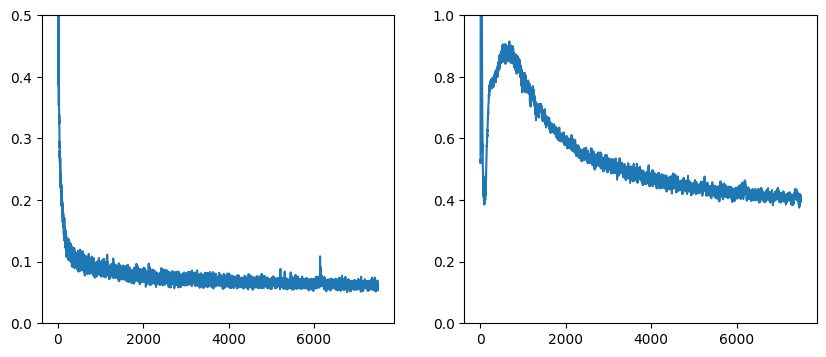

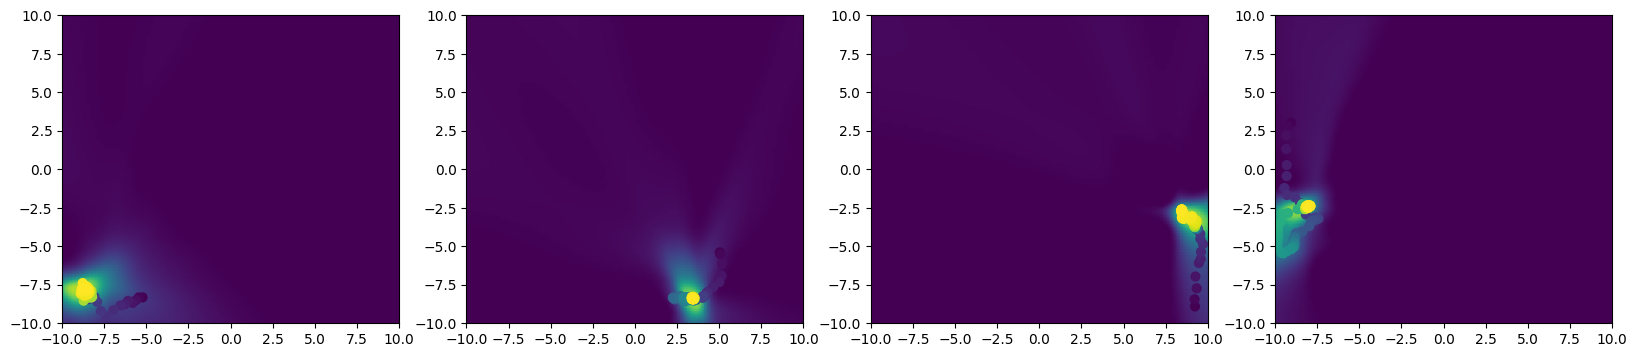

KeyboardInterrupt: 

In [30]:
for i in tqdm(range(20000), desc='VAE training', leave=False):
    vae_loss_dict = trajectory_encoder.train_step_VAE(
        batch_size=64,
        num_anchors=100,
        num_states=800,
        non_anchor_coef=1.,
        min_trajectory_size=1000,
        max_trajectory_size=1001,
    )
    vae_loss.append(vae_loss_dict['loss'])
    vae_kl_loss.append(vae_loss_dict['kl_loss'])
    
    if i % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(vae_loss)
        axs[0].set_ylim([0, 0.5])
        axs[1].plot(vae_kl_loss)
        axs[1].set_ylim([0, 1])
        plt.show()
        
        eval_num_envs = 4
        eval_z, info = trajectory_encoder.get_z_from_random_anchors(eval_num_envs, num_anchors=200, min_trajectory_size=1000, max_trajectory_size=1001)
        # eval_z, _ = reward_generator.get_z_from_prior(eval_num_envs)
        # base_z = info['base_z']

        anchors, anchors_rewards, pad_mask = info['anchors'], info['anchors_rewards'], info['pad_mask']

        fig, axs = visualize_rewards_and_trajectories(eval_z, trajectory_encoder, anchors, anchors_rewards, pad_mask)
        for i in range(eval_num_envs): axs[i].scatter(anchors[i, :, 0], anchors[i, :, 1], c=anchors_rewards[i], s=40)
        fig.show()
        plt.show()

In [16]:
import matplotlib.patches as patches


STATE_SCALE = 40

def add_largest_maze_walls(ax):
    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 0.025 * STATE_SCALE

    height, width = 7, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size
    # torso_x, torso_y = 0, 0

    # Get current axes
    # ax = plt.gca()

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size
        h, w = h * block_size * 2, w * block_size * 2
        
        w = w * 1.4
        y = y * 1.4
        
        rect = patches.Rectangle((x, y), h, w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)

    

def visualize_rewards_and_trajectories(eval_z, reward_generator, anchors=None, anchors_rewards=None, pad_mask=None, trajectories=None, select_max_trajectory=False):
    # eval_z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)

    # dataset_trajectories[:, 0].min(), dataset_trajectories[:, 0].max(), dataset_trajectories[:, 1].min(), dataset_trajectories[:, 1].max()

    s = 100
    x1_vals = np.linspace(dataset_trajectories[..., 0].min(), dataset_trajectories[..., 0].max(), s)
    x2_vals = np.linspace(dataset_trajectories[..., 1].min(), dataset_trajectories[..., 1].max(), s)

    # x1_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE
    # x2_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE

    # x1_vals = np.linspace(-0.3, 0.3, s)
    # x1_vals = np.round((x1_vals + 0.3) / 0.6 * 32)
    # x2_vals = np.linspace(-0.3, 0.3, s)
    # x2_vals = np.round((x2_vals + 0.3) / 0.6 * 32)



    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
    # print(X1.shape, X2.shape)

    state = torch.zeros((s*s, 4), dtype=torch.float32)
    state[:, :2] = torch.tensor(state_x12)
    state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
    state = state.to(device)


    num_evals = eval_z.shape[0]
    num_rows = int(np.floor(num_evals/4))
    num_rows += 1 if (num_rows == 0) or num_evals % (num_rows*4) != 0 else 0
    fig, axs = plt.subplots(num_rows, 4, figsize=(20, num_rows*4))
    axs = axs.flatten()

    for i in range(len(eval_z)):
        zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
        with torch.no_grad():
            r = reward_generator.get_reward(state[..., :2], zi).cpu()
        
        # axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.3, s=20)
        # axs[i].scatter(coods[:, 0].cpu(), coods[:, 1].cpu(), c='red', alpha=0.3, s=20)
        axs[i].pcolormesh(X1, X2, r.reshape(X1.shape), shading='gouraud', alpha=1, vmin=0.0, vmax=1)
        # axs[i].contourf(X1, X2, r.reshape(X1.shape), levels=20, alpha=1, vmin=0.1, vmax=1.0)
        
        if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
            
            anchors_rewards = anchors_rewards.clip(0, 1)
            anchors_rewards = anchors_rewards * 10
            anchors_rewards = anchors_rewards + 0.1
            
            anchors = np.where(~pad_mask[..., None], anchors, None)
            anchors_rewards = np.where(~pad_mask[..., None], anchors_rewards, 0)
            
            # print(anchors[i, :, 0].shape, anchors_rewards[i, :].shape)
            axs[i].scatter(anchors[i, :, 0], anchors[i, :, 1], c='red', s=anchors_rewards[i, :, 0].reshape(-1))
        # axs[i].scatter(anchors[i, -1, 0].cpu(), anchors[i, -1, 1].cpu(), c=anchors_rewards[i, -1, 0],  edgecolors='red', vmin=0, vmax=1)
        # axs[i].scatter(anchors[i, 0, 0].cpu(), anchors[i, 0, 1].cpu(), c='red', s=anchors_rewards[i, 0, 0].reshape(-1).cpu()*100)
        # axs[i].scatter(info['get_training_data:info']['base_anchors'][i, -1, 0].cpu(), info['get_training_data:info']['base_anchors'][i, -1, 1].cpu(), c='red', s=anchors_rewards[i, -1, 0].reshape(-1).cpu()*10)
        
        if trajectories is not None:
            if select_max_trajectory:
                # j = np.argmax([trajectories[j][0]['rewards'][TEMP_EPISODE_LENGTH*i:TEMP_EPISODE_LENGTH*(i+1)][-10:].mean() for j in range(len(trajectories))])
                max_j = np.argmax([trajectories[j][0]['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)].sum() for j in range(len(trajectories))])
                # trajectories = [trajectories[j]]
                
            for j in range(len(trajectories)):
                if select_max_trajectory:
                    j = max_j
                    
                trajectory, _ = trajectories[j]
                coords = trajectory['states'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1), :2]
                r_mean = trajectory['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)][-10:].mean()
                axs[i].scatter(coords[:, 0], coords[:, 1], s=10, c='black')
                
                axs[i].set_xlabel("X-Coordinates")
                axs[i].set_xlabel(f"{r_mean}")
                axs[i].set_ylabel("Y-Coordinates")
                
                if select_max_trajectory:
                    break
        
        # add_largest_maze_walls(axs[i])
        
        r_argmax = state[r.argmax(), :2].cpu()
        # axs[i].scatter(r_argmax[0].cpu(), r_argmax[1].cpu(), c='green', s=10)

    return fig, axs
    # plt.show()

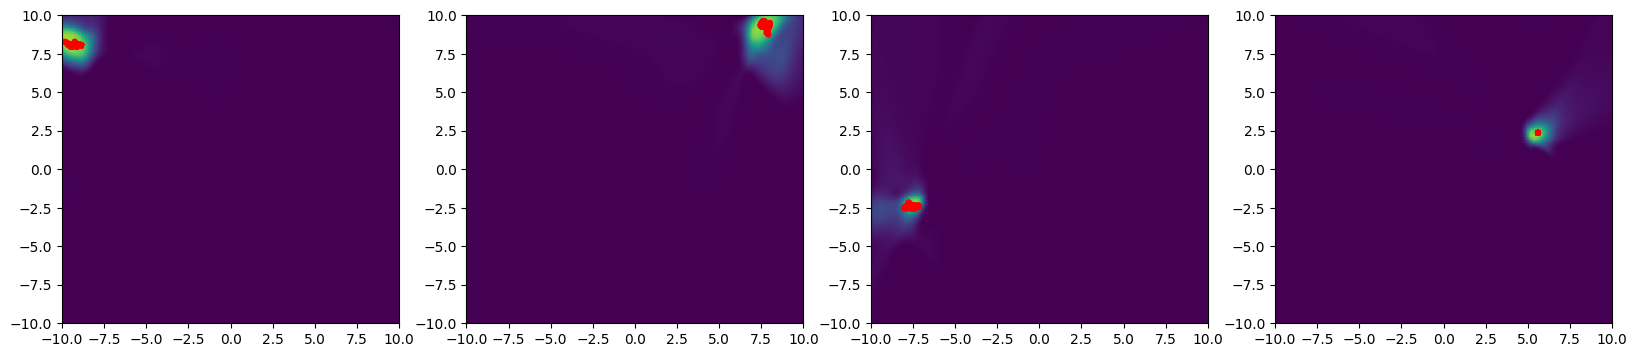

In [ ]:
eval_num_envs = 4
eval_z, info = trajectory_encoder.get_z_from_random_anchors(eval_num_envs, num_anchors=200, min_trajectory_size=100, max_trajectory_size=101)
# eval_z, _ = reward_generator.get_z_from_prior(eval_num_envs)
# base_z = info['base_z']

anchors, anchors_rewards, pad_mask = info['anchors'], info['anchors_rewards'], info['pad_mask']

fig, axs = visualize_rewards_and_trajectories(eval_z, trajectory_encoder, anchors, anchors_rewards, pad_mask)
# for i in range(eval_num_envs): axs[i].scatter(anchors[i, :, 0], anchors[i, :, 1], c=anchors_rewards[i], s=50)

# fig.show()

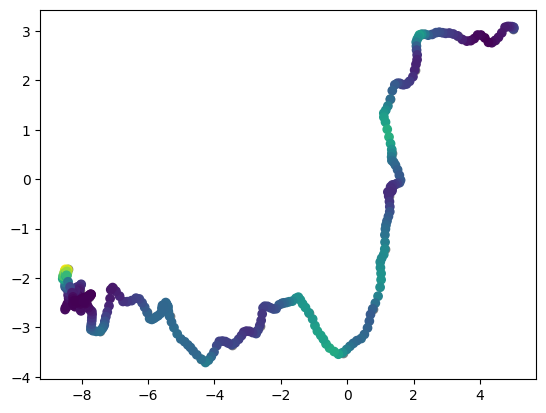

In [ ]:
rw = resampling_weights.reshape(-1, TRAJECTORY_LEN)

plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')

i = 0
plt.scatter(dataset_trajectories[i, :, 0], dataset_trajectories[i, :, 1], c=rw[i, :])

In [ ]:
dataset_goals.shape

torch.Size([1000000, 2])